## Background

**Dataset:** `sklearn.datasets.make_moons`

`make_moons` is a synthetic dataset from `sklearn` that generates a **two-class, two-dimensional** dataset shaped like two half-circles. Because the boundary between classes is curved, **no linear decision boundary can cleanly separate them**. In this lab, we will compare the three different SVM Kernels to see which performs best.



## Step 1: Setup: Load Libraries and Generate Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.datasets import make_moons
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)

Class distribution:
1    1000
0    1000
Name: count, dtype: int64


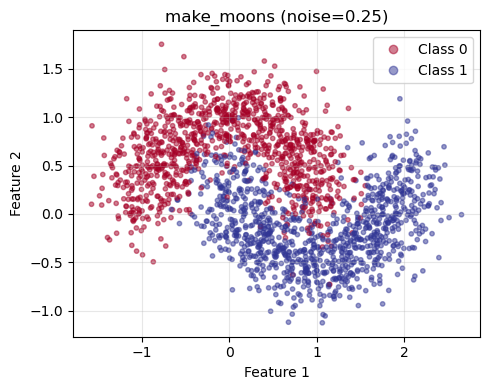

In [7]:

# The `noise` parameter adds Gaussian noise to the coordinates
# Higher noise blurs the boundary and makes the problem harder
# Too little noise makes it trivial

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

print(f"Class distribution:\n{pd.Series(y).value_counts()}")

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.5)
handles, _ = scatter.legend_elements()
ax.legend(handles, ['Class 0', 'Class 1'])
ax.set_title('make_moons (noise=0.25)') # Higher noise = harder to classify 
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset has two features and two balanced classes:

| Feature | Description |
|---------|-------------|
| `X[:, 0]` | x-coordinate (with noise) |
| `X[:, 1]` | y-coordinate (with noise) |



## Step 2: Preprocessing

SVMs are scale-variant, so we always apply `StandardScaler` before fitting. Split your data using `train_test_split` with a test_size of 0.3,  `random_state = 42`, and `stratify = y`. 

In [8]:
# Split 
X_train, X_test, y_train, y_test  = train_test_split(X, y, 
                                                     test_size=0.3, 
                                                     stratify=y, 
                                                     random_state=42)

# Scale
Scaler = StandardScaler().fit(X_train)
X_train_sc = Scaler.transform(X_train) 
X_test_sc = Scaler.transform(X_test) 

print(f"{len(X_train)}, {len(X_test)}")

1400, 600


---

## Background: Support Vector Classifier

The **support vector classifier** (SVC) fits a linear decision boundary by maximizing the margin between classes while allowing some observations to violate it. The penalty hyperparameter `C` controls how harshly violations are penalized:

- **Large C**( 100 to 1000): violations penalized heavily → narrow margin, fewer support vectors, tighter fit to training data
- **Small C** ( 0.0001 to 1): violations tolerated → wide margin, more support vectors, smoother boundary

## Step 3: Tune a Linear SVM with GridSearchCV

---

Use `GridSearchCV` with 5-fold cross-validation, search over the following values of `C` to find the best linear kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: .001, .01, 0.1, 1, 10, 100



In [9]:
# Tunning 
param_grid = {
    'C': [0.001,0.01,0.1,1,10,100]
}

# SVM with 
grid_linear = GridSearchCV(
    SVC(kernel = 'linear', 
        random_state=42), 
    param_grid,
    cv = 5, 
    scoring = "accuracy", 
    n_jobs=-1 # Using parelle processing (use more RAM)
)

grid_linear.fit(X_train_sc, y_train)

GridSearchCV(cv=5, estimator=SVC(kernel='linear', random_state=42), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

In [10]:
# Find best estimator 
svc_best = grid_linear.best_estimator_ 

# Find test accuracy 
svc_acc = accuracy_score(y_test, svc_best.predict(X_test_sc)) # Predict with best estimator 

# best parameter 
print(f"Best parameters:  {grid_linear.best_params_}")
print(f"CV accuracy:    {grid_linear.best_score_:.3f}")
print(f"Test accuracy:    {svc_acc:.3f}")


Best parameters:  {'C': 1}
CV accuracy:    0.860
Test accuracy:    0.880


##### Look at the accuracy each value of C yielded in `grid_linear`. Hint: You can access the cross validation results using `.cv_results`, then select only the `param_C` and `mean_test_score` column. Convert these results into a DataFrame for easier interpretation!

In [11]:
pd.DataFrame({
    'param_C' : grid_linear.cv_results_['param_C'],
    'mean_test_score': grid_linear.cv_results_['mean_test_score']
})

,param_C,mean_test_score
0,0.001,0.847143
1,0.01,0.853571
2,0.1,0.856429
3,1,0.860000
4,10,0.860000
5,100,0.860000


> **Q1: What `C` value did cross-validation select? Given that the moons boundary is curved, did you expect the linear kernel to achieve strong accuracy regardless of `C`? At what value of C does the accuracy stop improving?**

Cross validation selected a C of 1. The linear kernel was never going to achieve strong accuracy (regardless of C) because of the curved boundary within the data. The data structure is incompatable for a linear model. The value of C stops improving at 1. 

---

## Background: RBF Kernel

When the true decision boundary is non-linear, we replace the inner product in the SVC formulation with a **kernel function** that implicitly maps observations into a higher-dimensional space. The **radial basis function (RBF)** kernel measures similarity by distance:

$$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly influence decays with distance:

- **Large $\gamma$** → complex, local boundary (high variance risk)
- **Small $\gamma$** → smooth, global boundary (high bias risk)

Both `C` and `gamma` need to be tuned jointly via cross-validation.

## Step 4: Tune an RBF SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`,search over the following values of `C`,and `gamma` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: `scale`, 0.001, 0.01, 0.1, 1, 10

In [12]:
# Tunning 
param_grid = {
    'C': [0.1,1,10,100], 
    'gamma': ['scale',0.001, 0.01, 0.1, 1, 10]
}

# SVM with 
grid_rbf = GridSearchCV(
    SVC(kernel = 'rbf', # Change with kernal
        random_state=42), 
    param_grid,
    cv = 5, 
    scoring = "accuracy", 
    n_jobs=-1 # Using parelle processing (use more RAM)
)

grid_rbf.fit(X_train_sc, y_train)

# Find best estimator 
rbf_best = grid_rbf.best_estimator_ 

# Find test accuracy 
rbf_acc = accuracy_score(y_test, rbf_best.predict(X_test_sc)) # Predict with best estimator 

# best parameter 
print(f"Best parameters:  {grid_rbf.best_params_}")
print(f"CV accuracy:    {grid_rbf.best_score_:.3f}")
print(f"Test accuracy:    {rbf_acc:.3f}")


Best parameters:  {'C': 1, 'gamma': 1}
CV accuracy:    0.948
Test accuracy:    0.938


> **Q2: How much does the RBF kernel improve over the linear SVM? Do the best `C` and `gamma` values suggest a smooth or tightly-fitted boundary?**

RBF increased the accuracy score by 7%. The best parameters are C = 1 and gamma = 1. The C of 1 and Gamma of 1 produces a moderately flexible and smooth decision boundary.


---

## Background: Polynomial Kernel

The **polynomial kernel** of degree $d$ is:

$$K(x_i, x_j) = ( \gamma \langle x_i, x_j \rangle + r)^d$$


Higher degree allows the boundary to curve more, capturing complex feature interactions, but also increases the risk of overfitting. The `coef0` term (r in the formula above) weights the influence of lower-degree polynomial terms.

## Step 5: Tune a Polynomial SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `C`, `degree`, and `coef0` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: 'scale', 0.001, 0.01, 0.1, 1
`degree`: 2, 3, 4
`coef0`: 0.0, 1.0

In [13]:
# Tunning 
param_grid = {
    'C': [0.1, 1, 10, 100], 
    'gamma': ['scale', 0.001, 0.01, 0.1, 1], 
    'degree': [2, 3, 4], 
    'coef0': [0.0, 1.0]
}

# SVM with 
grid_poly = GridSearchCV(
    SVC(kernel = 'poly', # Change with kernal
        random_state=42), 
    param_grid,
    cv = 5, 
    scoring = "accuracy", 
    n_jobs=-1 # Using parelle processing (use more RAM)
)

grid_poly.fit(X_train_sc, y_train)

# Find best estimator 
poly_best = grid_poly.best_estimator_ 

# Find test accuracy 
poly_acc = accuracy_score(y_test, poly_best.predict(X_test_sc)) # Predict with best estimator 

# best parameter 
print(f"Best parameters:  {grid_poly.best_params_}")
print(f"CV accuracy:    {grid_poly.best_score_:.3f}")
print(f"Test accuracy:    {poly_acc:.3f}")


Best parameters:  {'C': 1, 'coef0': 1.0, 'degree': 3, 'gamma': 1}
CV accuracy:    0.945
Test accuracy:    0.940


> **Q3: Which degree polynomial did GridSearchCV select? How does the polynomial kernel's accuracy compare to the RBF kernel for this crescent-shaped data? Does a higher degree always help, and why or why not?**

A 3rd degree polynomial was selected. The polynomial kernel accuracy is similar to the RBF as both are around 0.940. 
A degree higher does not always help with the polynomial kernel. A higher degree polynomal can cause overfitting which is when the model is effected by the noise and fits the training set well and the test set poorly.

---

## Step 6: Streamlining the Hyperparameter Search

Rather than selecting a kernel first and tuning it separately, we can treat the kernel type itself as a hyperparameter. `GridSearchCV` accepts a list of parameter grids, letting each kernel specify its own relevant parameters in a single joint search. Create a joint search where each search grid we used above is included as a dictionary item, with its specified kernel included. `param_grid_all` should be a list of three dictionaries. Then, Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the parameter grid you created to find the best configuration. Report the best parameters, CV accuracy, and test accuracy.

In [14]:
param_grid_all = [
    {
        'kernel': ['linear'], 
        'C': [0.01, 0.1, 1, 10, 100]
    },

    {
        'kernel': ['rbf'], 
        'gamma': ['scale',0.001, 0.01, 0.1, 1, 10],   # scale conforms to your data 1/ (#features * variance of x)
        'C': [0.01, 0.1, 1, 10, 100]
    },

    {
        'kernel': ['poly'], 
        'gamma': ['scale', 0.001, 0.01, 0.1, 1],   # scale conforms to your data 1/ (#features * variance of x)
        'C': [0.01, 0.1, 1, 10, 100], 
        'degree': [2,3,4], 
        'coef0': [0,1]
    }

]

In [15]:
grid_overall = GridSearchCV(
    SVC(random_state=42), 
    param_grid=param_grid_all, 
    cv = 5, 
    scoring='accuracy', 
    n_jobs=-1
)

In [16]:
# Fit to trained data 
grid_overall.fit(X_train_sc, y_train)

best_overall = grid_overall.best_estimator_

test_acc_overall = accuracy_score(y_test, best_overall.predict(X_test_sc))

print(f"Best Parm: {grid_overall.best_params_}")
print(f"CV Accuracy: {grid_overall.best_score_:3f}")
print(f"Test Accuracy: {test_acc_overall:3f}")

Best Parm: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
CV Accuracy: 0.947857
Test Accuracy: 0.938333


> **Q4: Which kernel did the overall search select as best? Is this consistent with the cross validation accuracy from the individual kernel results? Given the curved, crescent-shaped structure of the moons data, does the winning kernel make intuitive sense?**

The RBF and polynomial performed very similarity. Yet, RBF was selected as the best kernel. This is consisent with the cross validation accuracy. RBF's CV accuracy score was the best score with a value of 0.948. This makes intuitive sense because the hyerparmeters (gamma and C) provide a way to account for violations ands bias and variance within the curved, crescent-shaped data structure. THe RBF deteremines the boundaries by looking at the points placement in comparision to eachother (investigating proximity between points) which allows the model to wrap around the data clusters. 

---
## Step 7: Tune a Random Forest with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `n_estimators`, `max_depth`, and `min_samples_leaf` to find the best random forest configuration. Report the best parameters, CV accuracy, and test accuracy.

`n_estimators`: 100, 200
`max_depth` : None, 5, 10
`min_samples_leaf`: 1, 5, 10

In [17]:
param_grid_rf = {
    'n_estimators': [100,200], 
    'max_depth':[None, 5, 10], 
    'min_samples_leaf': [1, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid_rf, 
    cv = 5, 
    scoring = 'accuracy', 
    n_jobs=-1
)

grid_rf.fit(X_train_sc, y_train)

best_rf = grid_rf.best_estimator_
test_acc_rf = accuracy_score(y_test, best_rf.predict(X_test_sc))
                             
print(f"Best Parm: {grid_rf.best_params_}")
print(f"CV Accuracy: {grid_rf.best_score_:3f}")
print(f"Test Accuracy: {test_acc_rf:3f}")

Best Parm: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
CV Accuracy: 0.946429
Test Accuracy: 0.938333


> **Q5:  How does the Random Forest test accuracy compare to the best SVM kernel?**

Random forests test accuracy score is 0.938. The best SVM kernal (the RBF) has a test accuracy score of 0.938. 
Therefore, these two tests have the same test accuracy scores. 

---

## Step 8: Visualize Decision Boundaries

Because `make_moons` has only two features, we can plot the full decision region for all four models. This is where the differences between kernels and the tree-based approach become visually obvious. Create four visualizations of the decision boundaries for each model above. Use  `DecisionBoundaryDisplay.from_estimator()` to create the visualizations. Add a title specifying the model/kernel used to each plot. 

Text(0.5, 1.0, 'RBF')

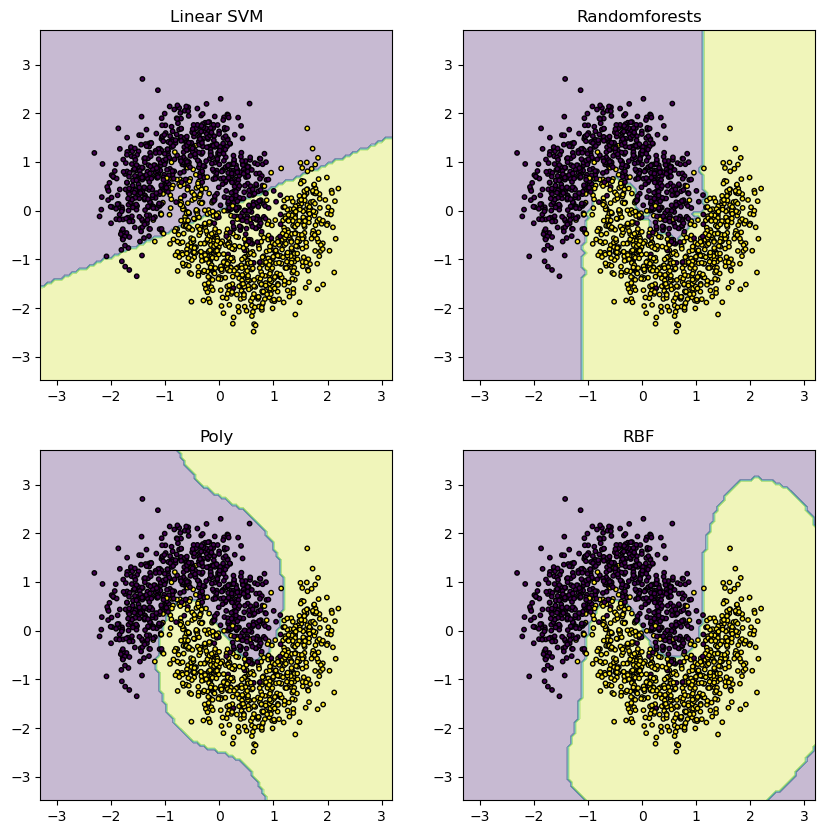

In [18]:
fig = plt.figure(figsize = (10,10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# SVC LINEAR ---------------
# Create Boundary 
DecisionBoundaryDisplay.from_estimator(svc_best, X_train_sc, ax = ax1, 
                                       response_method="predict", # predict decision boundaries with scaled 
                                       alpha = 0.3)

# Points on top of boundary 
ax1.scatter(X_train_sc[:, 0], X_train_sc[:,1], 
           c = y_train, 
           s = 10, 
           edgecolors = 'k')
ax1.set_title("Linear SVM")



# RANDOM FORESTS ---------------
# Create Boundary 
DecisionBoundaryDisplay.from_estimator(best_rf, X_train_sc, ax = ax2, 
                                       response_method="predict", # predict decision boundaries with scaled 
                                       alpha = 0.3)
# Points on top of boundary 
ax2.scatter(X_train_sc[:, 0], X_train_sc[:,1], 
           c = y_train, 
           s = 10, 
           edgecolors = 'k')
ax2.set_title("Randomforests")

# POLYNOMIAL ---------------
# Create Boundary 
DecisionBoundaryDisplay.from_estimator(poly_best, X_train_sc, ax = ax3, 
                                       response_method="predict", # predict decision boundaries with scaled 
                                       alpha = 0.3)
# Points on top of boundary 
ax3.scatter(X_train_sc[:, 0], X_train_sc[:,1], 
           c = y_train, 
           s = 10, 
           edgecolors = 'k')
ax3.set_title("Poly")

# SVC RBF ---------------
# Create Boundary 
DecisionBoundaryDisplay.from_estimator(rbf_best, X_train_sc, ax = ax4, 
                                       response_method="predict", # predict decision boundaries with scaled 
                                       alpha = 0.3)
# Points on top of boundary 
ax4.scatter(X_train_sc[:, 0], X_train_sc[:,1], 
           c = y_train, 
           s = 10, 
           edgecolors = 'k')
ax4.set_title("RBF")

> **Q6: How does the linear kernel's decision boundary compare visually to the RBF, polynomial, and Random Forest boundaries? How does the Random Forest boundary differ from the SVM boundaries?**

Unlike the RBF, polynomial, and Random Forest boundaries, the linear kernel decision boundary does not conform to the curved, crescent-shaped data structure. Thus, the linear kernel does not perfom well in distinguishing between the 2 classes. 

All the RBF, polynomial, and Random Forest boundaries weave between the classes well and similary. They mostly differ in how they classify the surrounding area. For instance, the Random Forest model laces between the classes like the other models but then the boundary extends directly up and down. The SVC Poly and RBF surrounding classification boundaries attempt to curve with the crescent-shap data. 


---

## Step 9: Model Comparison


### Confusion Matrices 

Accuracy alone can hide where models differ in their error patterns. Confusion matrices break down false positives and false negatives. 

##### Create a confusion matrix for each of the four models above. 

Text(0.5, 1.0, 'RBF')

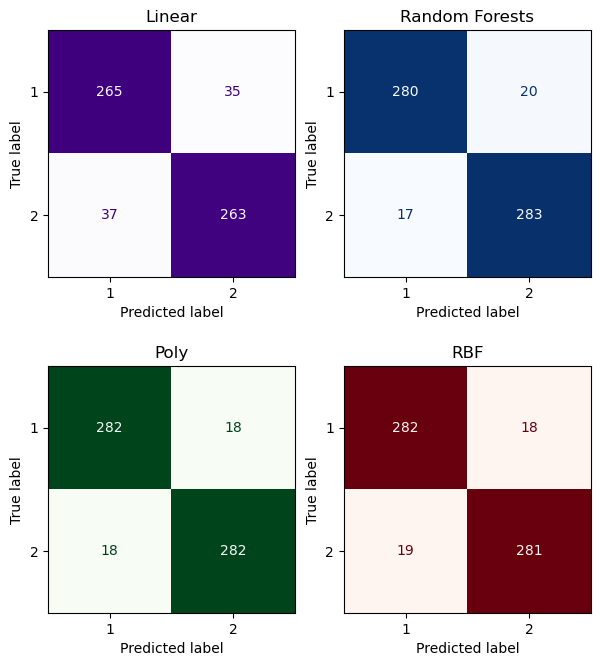

In [19]:
fig = plt.figure(figsize = (7,8))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# LINEAR -------------
cm_linear = confusion_matrix(y_test, svc_best.predict(X_test_sc))
disp_linear = ConfusionMatrixDisplay(confusion_matrix= cm_linear, 
                                     display_labels=['1', '2'])
disp_linear.plot(ax = ax1, colorbar = False, cmap = 'Purples')
ax1.set_title("Linear")

# RANDOM FOREST -------------
cm_rf = confusion_matrix(y_test, best_rf.predict(X_test_sc))
disp_rf = ConfusionMatrixDisplay(confusion_matrix= cm_rf,
                                     display_labels=['1', '2'])
disp_rf.plot(ax = ax2, colorbar = False, cmap = 'Blues')
ax2.set_title("Random Forests")

#  POLY ---------------
cm_poly = confusion_matrix(y_test, poly_best.predict(X_test_sc))
disp_poly = ConfusionMatrixDisplay(confusion_matrix= cm_poly, 
                                   display_labels=['1', '2'])
disp_poly.plot(ax = ax3, colorbar = False, cmap = 'Greens')
ax3.set_title("Poly")

# RBF ---------------
cm_rbf = confusion_matrix(y_test, rbf_best.predict(X_test_sc))
disp_rbf = ConfusionMatrixDisplay(confusion_matrix= cm_rbf, 
                                  display_labels=['1', '2'])
disp_rbf.plot(ax = ax4, colorbar = False, cmap = 'Reds')
ax4.set_title("RBF")

>**Q7:Comment on the results of the confusion matrices. Did all four models have similar misclassifications?**

RBF, polynomial, and Random Forest models have similar confusion matrices with approximately 18 false positives and 19 false negatives for all 3 models. 
The linear model shows the lowest accuracy with more false positives (37), more false negatives (35), and thus less correctly predicted negatives and positives. 


### ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate against the false positive rate as the classification threshold varies. A random classifier follows the diagonal (AUC = 0.50); a perfect classifier has AUC = 1.0.

**AUC (Area Under the Curve)** summarizes the entire ROC curve in a single number that makes it easy to compare different models.

**How ROC works for SVMs specifically:**
Unlike logistic regression, a standard SVC does not output class probabilities. Instead, it computes a decision function — the signed distance of each observation from the decision boundary. Points far on the positive side get large positive scores; points far on the negative side get large negative scores. `RocCurveDisplay.from_estimator` uses this decision function to build the ROC curve.

This means the ROC curve reflects how well each kernel's decision function ranks observations, independent of where the hard boundary is drawn.

##### Plot the ROC Curves for each of the four models on the same plot. Add a line indicating a random classifier (ACU = 0.5) and a legend. 


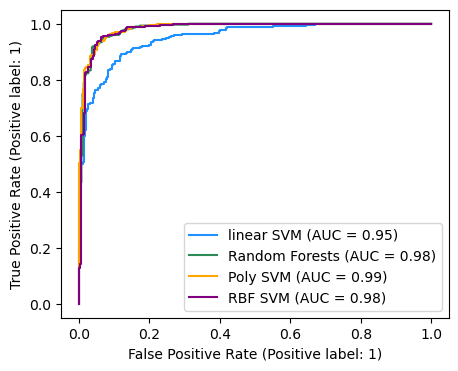

In [20]:
fig, ax = plt.subplots(figsize = (5,4))

RocCurveDisplay.from_estimator(svc_best, X_test_sc, y_test, name = "linear SVM", ax = ax, color = 'Dodgerblue')
RocCurveDisplay.from_estimator(best_rf, X_test_sc, y_test, name = "Random Forests", ax = ax, color = 'Seagreen')
RocCurveDisplay.from_estimator(poly_best, X_test_sc, y_test, name = "Poly SVM", ax = ax, color = 'Orange')
RocCurveDisplay.from_estimator(rbf_best, X_test_sc, y_test, name = "RBF SVM", ax = ax, color = 'Purple')

> **Q8: Do the AUC values align with what you observed in the confusion matrices and accuracy scores? How does the Random Forest compare to the SVM kernels across all three metrics? Considering accuracy, AUC, and the decision boundary shape, which model would you choose for this dataset and why?**

In [24]:
# Compare CV and test accuracy scores 
pd.DataFrame({
    'Model' : ['linear','RBF', 'poly', 'Random Forest'],
    'CV Scores': [grid_linear.best_score_, grid_rbf.best_score_, grid_poly.best_score_, grid_rf.best_score_], 
    'test Scores': [svc_acc, rbf_acc, poly_acc, test_acc_rf]
})

,Model,CV Scores,test Scores
0,linear,0.860000,0.880000
1,RBF,0.947857,0.938333
2,poly,0.945000,0.940000
3,Random Forest,0.946429,0.938333


The AUC values align with the confusion matrices and accuracy scores: The linear kernel has the worst ROC AUC curve and the other three models performance is similar. 
The Random Forests results are very similar to SVM polynomial and RBF kernels. Their AUC values, confusion matrix results, and the CV and test accuracy scores are very alike. 

I would choose the Polynomal kernel because that model had a good CV and test accuracy score combination and confusion matrix.

>**Q9: In terms of overall perforamnce, why does the linear kernel not perform as well as the RBF kernel, Polynomial Kernel, or Random Forest. What is a difference between these latter three models and the former that impacts the shape of the decision boundary and overall accuracy.**

Linear SCV is a parameteric model that assumes a linear-shaped boundary line. The latter three models are nonparameter, and therefore do not assume a functional form of f. With the differing hyperparamters, the models allow the boundary to be flexible to non-linear data structure. 